# Inverse mixed PINN for identification of a spatially varying body force

The goal is to approximate two displacement components, three stress components, and the unknown body-force vector on

$$
\Omega=(0,1)^2.
$$

Young's modulus and Poisson's ratio are known constants,

$$
E=1,
\qquad
\nu=\frac14,
\qquad
\lambda=\mu=\frac25.
$$

Seven independent scalar-output neural networks approximate

$$
u_{1,\theta},\quad u_{2,\theta},\quad
\sigma_{xx,\theta},\quad \sigma_{yy,\theta},\quad \sigma_{xy,\theta},\quad
b_{1,\theta},\quad b_{2,\theta}.
$$

For the synthetic inverse experiment, the exact displacement is

$$
\mathbf u_{\mathrm{exact}}(x,y)=a
\begin{bmatrix}
\cos x-y^2\\
2\sin x+y
\end{bmatrix},
\qquad a=0.005.
$$

The corresponding hidden body force is

$$
\mathbf b_{\mathrm{exact}}(x,y)=
\begin{bmatrix}
0.006\cos x+0.004\\
0.004\sin x
\end{bmatrix}.
$$

The exact body force is never used in the loss. It is used only after training to evaluate the identified function.

## Strong formulation

The infinitesimal-strain tensor, constitutive law, and equilibrium equation are

$$
\boldsymbol\varepsilon(\mathbf u)=\frac12\left(\nabla\mathbf u+\nabla\mathbf u^{\mathsf T}\right),
\qquad
\boldsymbol\sigma=\lambda\operatorname{tr}(\boldsymbol\varepsilon)\mathbf I+2\mu\boldsymbol\varepsilon,
\qquad
\nabla\cdot\boldsymbol\sigma+\mathbf b=\mathbf0.
$$

Boundary conditions are not included in the loss. Observations of the two displacement and three stress components are always used and may be exact or Gaussian-noisy.


## 1. Library imports


In [46]:
import numpy as np
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
from torch.utils.data import DataLoader, TensorDataset


## 2. Configuration

- Young's modulus and Poisson's ratio are known and fixed.
- Seven independent scalar-output networks approximate the displacement, stress, and body-force components.
- Observations of the two displacement and three stress components are always included.
- `USE_NOISY_DATA = False` uses exact observations.
- `USE_NOISY_DATA = True` adds independent zero-mean Gaussian noise with standard deviation $s_{\mathrm{noise}}=0.02a$.
- `WEIGHT_EQUILIBRIUM`, `WEIGHT_CONSTITUTIVE`, `WEIGHT_DATA`, and `WEIGHT_REGULARIZATION` control the loss contributions.
- The body-force regularizer is evaluated by the two-dimensional midpoint rectangle rule.
- Adam uses PDE mini-batches, whereas L-BFGS uses a fixed full batch.


In [47]:
USE_NOISY_DATA = True

E, NU = 1.0, 0.25
LAMBDA = E * NU / ((1.0 + NU) * (1.0 - 2.0 * NU))
MU = E / (2.0 * (1.0 + NU))
AMPLITUDE = 0.005
NOISE_STD = 0.02 * AMPLITUDE

WEIGHT_EQUILIBRIUM = 1.0
WEIGHT_CONSTITUTIVE = 1.0
WEIGHT_DATA = 1000.0
WEIGHT_REGULARIZATION = 1e-9

N_PDE_TRAIN = 3000
N_PDE_VALIDATION = 1500
N_PDE_TEST = 1500
PDE_BATCH_SIZE = 200
N_REGULARIZATION_X = 40
N_REGULARIZATION_Y = 40
N_DATA_TRAIN = 30
N_DATA_VALIDATION = 7
N_DATA_TEST = 7
EPOCHS = 2000
LBFGS_EPOCHS = 100
LR = 1e-3
SEED = 42

torch.manual_seed(SEED)
print(f"Known E = {E:.6f}, known nu = {NU:.6f}")
print(f"Data mode: {'noisy' if USE_NOISY_DATA else 'exact'}, noise standard deviation = {NOISE_STD:.6e}")
print(f"Loss weights: equilibrium={WEIGHT_EQUILIBRIUM:g}, constitutive={WEIGHT_CONSTITUTIVE:g}, data={WEIGHT_DATA:g}, regularization={WEIGHT_REGULARIZATION:g}")


Known E = 1.000000, known nu = 0.250000
Data mode: noisy, noise standard deviation = 1.000000e-04
Loss weights: equilibrium=1, constitutive=1, data=1000, regularization=1e-09


## 3. Exact displacement, stress, and hidden body force


In [48]:
def exact_displacement(xy):
    x, y = xy[:, 0:1], xy[:, 1:2]
    u1 = AMPLITUDE * (torch.cos(x) - y**2)
    u2 = AMPLITUDE * (2.0 * torch.sin(x) + y)
    return torch.cat((u1, u2), dim=1)

def exact_stress(xy):
    x, y, a = xy[:, 0:1], xy[:, 1:2], AMPLITUDE
    eps_xx, eps_yy, eps_xy = -a * torch.sin(x), a * torch.ones_like(x), a * (torch.cos(x) - y)
    trace_eps = eps_xx + eps_yy
    sigma_xx = LAMBDA * trace_eps + 2.0 * MU * eps_xx
    sigma_yy = LAMBDA * trace_eps + 2.0 * MU * eps_yy
    sigma_xy = 2.0 * MU * eps_xy
    return torch.cat((sigma_xx, sigma_yy, sigma_xy), dim=1)

def exact_fields(xy):
    return torch.cat((exact_displacement(xy), exact_stress(xy)), dim=1)

def exact_body_force(xy):
    x, a = xy[:, 0:1], AMPLITUDE
    b1 = a * (LAMBDA + 2.0 * MU) * torch.cos(x) + 2.0 * MU * a
    b2 = 2.0 * MU * a * torch.sin(x)
    return torch.cat((b1, b2), dim=1)


## 4. Seven independent neural networks

One independent scalar-output network is used for each field:

$$
\mathcal N_{u_1},\quad \mathcal N_{u_2},\quad
\mathcal N_{\sigma_{xx}},\quad \mathcal N_{\sigma_{yy}},\quad \mathcal N_{\sigma_{xy}},\quad
\mathcal N_{b_1},\quad \mathcal N_{b_2}.
$$

The networks do not share weights or biases. Each has five hidden layers with 20 neurons per layer and the $\tanh$ activation function. The two body-force networks are trained together with the displacement and stress networks.


In [49]:
class FieldNetwork(nn.Module):
    def __init__(self):
        super().__init__()
        self.net = nn.Sequential(nn.Linear(2, 20), nn.Tanh(), nn.Linear(20, 20), nn.Tanh(), nn.Linear(20, 20), nn.Tanh(), nn.Linear(20, 20), nn.Tanh(), nn.Linear(20, 20), nn.Tanh(), nn.Linear(20, 1))

    def forward(self, xy):
        return self.net(xy)

class IndependentMixedBodyForcePINN(nn.Module):
    def __init__(self):
        super().__init__()
        self.u1_network = FieldNetwork()
        self.u2_network = FieldNetwork()
        self.sigma_xx_network = FieldNetwork()
        self.sigma_yy_network = FieldNetwork()
        self.sigma_xy_network = FieldNetwork()
        self.b1_network = FieldNetwork()
        self.b2_network = FieldNetwork()

    def forward(self, xy):
        u1, u2 = self.u1_network(xy), self.u2_network(xy)
        sigma_xx, sigma_yy, sigma_xy = self.sigma_xx_network(xy), self.sigma_yy_network(xy), self.sigma_xy_network(xy)
        return torch.cat((u1, u2, sigma_xx, sigma_yy, sigma_xy), dim=1)

    def body_force(self, xy):
        return torch.cat((self.b1_network(xy), self.b2_network(xy)), dim=1)

model = IndependentMixedBodyForcePINN()
optimizer_adam = torch.optim.Adam(model.parameters(), lr=LR)


## 5. Training, validation, test, and regularization points

The PDE training, validation, and test points form three separately shifted uniform Cartesian grids. The supervised data locations are generated independently at random. A separate uniform midpoint grid is used for the body-force regularization integral. Observations are always included in the inverse loss and are either exact or Gaussian-noisy according to `USE_NOISY_DATA`. Boundary points are not generated because boundary conditions are excluded from the loss.


In [50]:
def uniform_grid(n_points, offset_x=0.5, offset_y=0.5):
    n_x = int(np.sqrt(n_points))
    while n_points % n_x != 0:
        n_x -= 1
    n_y = n_points // n_x
    x = (torch.arange(n_x, dtype=torch.float32) + offset_x) / n_x
    y = (torch.arange(n_y, dtype=torch.float32) + offset_y) / n_y
    X, Y = torch.meshgrid(x, y, indexing='xy')
    return torch.stack((X.reshape(-1), Y.reshape(-1)), dim=1)

def observed_fields(xy, seed):
    exact = exact_fields(xy)
    if not USE_NOISY_DATA:
        return exact
    generator = torch.Generator().manual_seed(seed)
    noise = NOISE_STD * torch.randn(exact.shape, generator=generator, dtype=exact.dtype)
    return exact + noise

pde_train_generator = torch.Generator().manual_seed(SEED + 1)
xy_pde_train = uniform_grid(N_PDE_TRAIN, 0.50, 0.50)
xy_pde_validation = uniform_grid(N_PDE_VALIDATION, 0.25, 0.25)
xy_pde_test = uniform_grid(N_PDE_TEST, 0.75, 0.75)
pde_loader = DataLoader(TensorDataset(xy_pde_train), batch_size=PDE_BATCH_SIZE, shuffle=True, generator=pde_train_generator)

REGULARIZATION_DX = 1.0 / N_REGULARIZATION_X
REGULARIZATION_DY = 1.0 / N_REGULARIZATION_Y
x_regularization = (torch.arange(N_REGULARIZATION_X, dtype=torch.float32) + 0.5) * REGULARIZATION_DX
y_regularization = (torch.arange(N_REGULARIZATION_Y, dtype=torch.float32) + 0.5) * REGULARIZATION_DY
X_regularization, Y_regularization = torch.meshgrid(x_regularization, y_regularization, indexing="xy")
xy_regularization = torch.stack((X_regularization.reshape(-1), Y_regularization.reshape(-1)), dim=1)

xy_data_train = torch.rand(N_DATA_TRAIN, 2, generator=torch.Generator().manual_seed(SEED + 3))
xy_data_validation = torch.rand(N_DATA_VALIDATION, 2, generator=torch.Generator().manual_seed(SEED + 11))
xy_data_test = torch.rand(N_DATA_TEST, 2, generator=torch.Generator().manual_seed(SEED + 4))
fields_data_train = observed_fields(xy_data_train, SEED + 20)
fields_data_validation = observed_fields(xy_data_validation, SEED + 21)
fields_data_test = observed_fields(xy_data_test, SEED + 22)


## 6. Equilibrium, constitutive, and regularization terms

The equilibrium residual contains the identified body force:

$$
\mathbf r_{\mathrm{eq},\theta}=\nabla\cdot\boldsymbol\sigma_\theta+\mathbf b_\theta.
$$

Because the stress components are approximated independently, the constitutive residual is

$$
\mathbf r_{\mathrm{const},\theta}=\boldsymbol\sigma_\theta-\left[\lambda\operatorname{tr}(\boldsymbol\varepsilon(\mathbf u_\theta))\mathbf I+2\mu\boldsymbol\varepsilon(\mathbf u_\theta)\right],
$$

where $\lambda$ and $\mu$ are known constants. Smoothness of the identified body force is encouraged through

$$
\mathcal L_{\mathrm{reg}}
=\int_\Omega\left\|\nabla\mathbf b_\theta\right\|_F^2\,\mathrm d\Omega
\approx
\Delta x\,\Delta y\sum_{i=1}^{N_x}\sum_{j=1}^{N_y}
\left\|\nabla\mathbf b_\theta(x_i^*,y_j^*)\right\|_F^2,
$$

where $(x_i^*,y_j^*)$ are cell midpoints and

$$
\left\|\nabla\mathbf b_\theta\right\|_F^2
=\left(\frac{\partial b_{1,\theta}}{\partial x}\right)^2
+\left(\frac{\partial b_{1,\theta}}{\partial y}\right)^2
+\left(\frac{\partial b_{2,\theta}}{\partial x}\right)^2
+\left(\frac{\partial b_{2,\theta}}{\partial y}\right)^2.
$$

The weighted training loss is

$$
\mathcal L=w_{\mathrm{eq}}\mathcal L_{\mathrm{eq}}+w_{\mathrm{const}}\mathcal L_{\mathrm{const}}+w_{\mathrm{data}}\mathcal L_{\mathrm{data}}+w_{\mathrm{reg}}\mathcal L_{\mathrm{reg}}.
$$

No exact body-force data and no boundary-condition loss are used. As in the one-dimensional example, the validation loss contains the equilibrium, constitutive, and data terms, but it does not contain the training regularizer.


In [51]:
def split_prediction(prediction):
    return prediction[:, 0:1], prediction[:, 1:2], prediction[:, 2:3], prediction[:, 3:4], prediction[:, 4:5]

def constitutive_stress_from_displacement(xy, u1, u2, create_graph):
    grad_u1 = torch.autograd.grad(u1, xy, grad_outputs=torch.ones_like(u1), create_graph=create_graph, retain_graph=True)[0]
    grad_u2 = torch.autograd.grad(u2, xy, grad_outputs=torch.ones_like(u2), create_graph=create_graph, retain_graph=True)[0]
    eps_xx, eps_yy = grad_u1[:, 0:1], grad_u2[:, 1:2]
    eps_xy = 0.5 * (grad_u1[:, 1:2] + grad_u2[:, 0:1])
    trace_eps = eps_xx + eps_yy
    sigma_xx = LAMBDA * trace_eps + 2.0 * MU * eps_xx
    sigma_yy = LAMBDA * trace_eps + 2.0 * MU * eps_yy
    sigma_xy = 2.0 * MU * eps_xy
    return torch.cat((sigma_xx, sigma_yy, sigma_xy), dim=1)

def mixed_residuals(xy, training=True):
    xy = xy.detach().clone().requires_grad_(True)
    prediction = model(xy)
    u1, u2, sigma_xx, sigma_yy, sigma_xy = split_prediction(prediction)
    predicted_stress = torch.cat((sigma_xx, sigma_yy, sigma_xy), dim=1)
    residual_constitutive = predicted_stress - constitutive_stress_from_displacement(xy, u1, u2, create_graph=training)
    grad_sigma_xx = torch.autograd.grad(sigma_xx, xy, grad_outputs=torch.ones_like(sigma_xx), create_graph=training, retain_graph=True)[0]
    grad_sigma_yy = torch.autograd.grad(sigma_yy, xy, grad_outputs=torch.ones_like(sigma_yy), create_graph=training, retain_graph=True)[0]
    grad_sigma_xy = torch.autograd.grad(sigma_xy, xy, grad_outputs=torch.ones_like(sigma_xy), create_graph=training, retain_graph=True)[0]
    predicted_body_force = model.body_force(xy)
    residual_1 = grad_sigma_xx[:, 0:1] + grad_sigma_xy[:, 1:2] + predicted_body_force[:, 0:1]
    residual_2 = grad_sigma_xy[:, 0:1] + grad_sigma_yy[:, 1:2] + predicted_body_force[:, 1:2]
    return torch.cat((residual_1, residual_2), dim=1), residual_constitutive, prediction

def body_force_jacobian_regularization(xy, training=True):
    xy = xy.detach().clone().requires_grad_(True)
    body_force = model.body_force(xy)
    gradient_b1 = torch.autograd.grad(body_force[:, 0:1], xy, grad_outputs=torch.ones_like(body_force[:, 0:1]), create_graph=training, retain_graph=True)[0]
    gradient_b2 = torch.autograd.grad(body_force[:, 1:2], xy, grad_outputs=torch.ones_like(body_force[:, 1:2]), create_graph=training, retain_graph=True)[0]
    jacobian_squared_norm = torch.sum(gradient_b1**2, dim=1) + torch.sum(gradient_b2**2, dim=1)
    return REGULARIZATION_DX * REGULARIZATION_DY * torch.sum(jacobian_squared_norm)

def compute_losses(xy_pde):
    residual_eq, residual_const, _ = mixed_residuals(xy_pde, training=True)
    loss_equilibrium = torch.mean(residual_eq**2)
    loss_constitutive = torch.mean(residual_const**2)
    loss_data = torch.mean((model(xy_data_train) - fields_data_train)**2)
    loss_regularization = body_force_jacobian_regularization(xy_regularization, training=True)
    loss = WEIGHT_EQUILIBRIUM * loss_equilibrium + WEIGHT_CONSTITUTIVE * loss_constitutive + WEIGHT_DATA * loss_data + WEIGHT_REGULARIZATION * loss_regularization
    return loss, loss_equilibrium, loss_constitutive, loss_data, loss_regularization

def compute_validation_losses():
    residual_eq, residual_const, _ = mixed_residuals(xy_pde_validation, training=False)
    loss_validation_equilibrium = torch.mean(residual_eq.detach()**2)
    loss_validation_constitutive = torch.mean(residual_const.detach()**2)
    with torch.no_grad():
        loss_validation_data = torch.mean((model(xy_data_validation) - fields_data_validation)**2)
    loss_validation = WEIGHT_EQUILIBRIUM * loss_validation_equilibrium + WEIGHT_CONSTITUTIVE * loss_validation_constitutive + WEIGHT_DATA * loss_validation_data
    return loss_validation, loss_validation_equilibrium, loss_validation_constitutive, loss_validation_data


## 7. Training, validation, and best-epoch selection


In [52]:
loss_history, equilibrium_loss_history, constitutive_loss_history, data_loss_history, regularization_loss_history = [], [], [], [], []
validation_loss_history, validation_equilibrium_loss_history = [], []
validation_constitutive_loss_history, validation_data_loss_history = [], []
ADAM_EPOCHS = EPOCHS - LBFGS_EPOCHS
best_validation_loss, best_epoch, best_model_state = float("inf"), None, None

def clone_model_state():
    return {name: value.detach().clone() for name, value in model.state_dict().items()}

def update_validation_checkpoint(epoch):
    global best_validation_loss, best_epoch, best_model_state
    validation, validation_eq, validation_const, validation_data = compute_validation_losses()
    values = validation.item(), validation_eq.item(), validation_const.item(), validation_data.item()
    validation_loss_history.append(values[0])
    validation_equilibrium_loss_history.append(values[1])
    validation_constitutive_loss_history.append(values[2])
    validation_data_loss_history.append(values[3])
    if best_model_state is None or values[0] < best_validation_loss:
        best_validation_loss, best_epoch, best_model_state = values[0], epoch, clone_model_state()
    return values[0]

scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer_adam, mode="min", factor=0.5, patience=200)

for epoch in range(ADAM_EPOCHS):
    epoch_sums = np.zeros(5)
    for (xy_pde_batch,) in pde_loader:
        optimizer_adam.zero_grad()
        losses = compute_losses(xy_pde_batch)
        losses[0].backward()
        optimizer_adam.step()
        epoch_sums += np.array([value.detach().item() for value in losses])
    loss_value, equilibrium_value, constitutive_value, data_value, regularization_value = epoch_sums / len(pde_loader)
    scheduler.step(loss_value)
    loss_history.append(loss_value)
    equilibrium_loss_history.append(equilibrium_value)
    constitutive_loss_history.append(constitutive_value)
    data_loss_history.append(data_value)
    regularization_loss_history.append(regularization_value)
    validation_value = update_validation_checkpoint(epoch)
    if epoch % 500 == 0:
        print(f"Adam | epoch {epoch:5d} | loss={loss_value:.6e} | eq={equilibrium_value:.6e} | const={constitutive_value:.6e} | data={data_value:.6e} | reg={regularization_value:.6e} | validation={validation_value:.6e}")

print(f"Switching from Adam to full-batch L-BFGS at epoch {ADAM_EPOCHS}.")
optimizer_lbfgs = torch.optim.LBFGS(model.parameters(), lr=0.1, max_iter=20, history_size=10, line_search_fn="strong_wolfe")

for lbfgs_epoch in range(LBFGS_EPOCHS):
    epoch = ADAM_EPOCHS + lbfgs_epoch
    def closure():
        optimizer_lbfgs.zero_grad()
        loss = compute_losses(xy_pde_train)[0]
        loss.backward()
        return loss
    optimizer_lbfgs.step(closure)
    loss, loss_eq, loss_const, loss_data, loss_regularization = compute_losses(xy_pde_train)
    loss_history.append(loss.detach().item())
    equilibrium_loss_history.append(loss_eq.detach().item())
    constitutive_loss_history.append(loss_const.detach().item())
    data_loss_history.append(loss_data.detach().item())
    regularization_loss_history.append(loss_regularization.detach().item())
    validation_value = update_validation_checkpoint(epoch)
    if lbfgs_epoch % 50 == 0 or lbfgs_epoch == LBFGS_EPOCHS - 1:
        print(f"L-BFGS | epoch {epoch:5d} | loss={loss.item():.6e} | eq={loss_eq.item():.6e} | const={loss_const.item():.6e} | data={loss_data.item():.6e} | reg={loss_regularization.item():.6e} | validation={validation_value:.6e}")

last_model_state = clone_model_state()
model.load_state_dict(best_model_state)
model.eval()
print(f"Best epoch: {best_epoch}, best validation loss: {best_validation_loss:.6e}")


Adam | epoch     0 | loss=7.453882e+00 | eq=9.667248e-04 | const=1.164619e-02 | data=7.441269e-03 | reg=2.462674e-04 | validation=8.722094e-01
Adam | epoch   500 | loss=7.902816e-05 | eq=1.240755e-07 | const=2.355499e-07 | data=7.866853e-08 | reg=2.912466e-05 | validation=3.555378e-05
Adam | epoch  1000 | loss=1.074451e-05 | eq=4.397933e-07 | const=8.151524e-08 | data=1.022320e-08 | reg=2.370383e-05 | validation=2.951129e-05
Adam | epoch  1500 | loss=3.260494e-05 | eq=6.021356e-09 | const=1.278096e-07 | data=3.247111e-08 | reg=2.330832e-05 | validation=3.228192e-05
Switching from Adam to full-batch L-BFGS at epoch 1900.
L-BFGS | epoch  1900 | loss=7.554533e-06 | eq=1.331550e-09 | const=9.662929e-08 | data=7.456572e-09 | reg=2.270275e-05 | validation=1.564309e-05
L-BFGS | epoch  1950 | loss=7.554533e-06 | eq=1.331550e-09 | const=9.662929e-08 | data=7.456572e-09 | reg=2.270275e-05 | validation=1.564309e-05
L-BFGS | epoch  1999 | loss=7.554533e-06 | eq=1.331550e-09 | const=9.662929e-08 | 

## 8. Testing the restored best model on independent points


In [53]:
model.eval()
residual_eq_test, residual_const_test, prediction_test = mixed_residuals(xy_pde_test, training=False)
exact_test, prediction_test = exact_fields(xy_pde_test).detach(), prediction_test.detach()
with torch.no_grad():
    body_force_prediction = model.body_force(xy_pde_test).detach()
    body_force_exact = exact_body_force(xy_pde_test)
u_prediction, u_exact = prediction_test[:, 0:2], exact_test[:, 0:2]
stress_prediction, stress_exact = prediction_test[:, 2:5], exact_test[:, 2:5]

def r2_score(prediction, exact):
    ss_res = torch.sum((prediction - exact)**2)
    ss_tot = torch.sum((exact - torch.mean(exact))**2)
    return (1.0 - ss_res / ss_tot).item()

def relative_l2(prediction, exact):
    return (torch.linalg.vector_norm(prediction - exact) / torch.linalg.vector_norm(exact)).item()

r2_u, relative_l2_u = r2_score(u_prediction, u_exact), relative_l2(u_prediction, u_exact)
r2_stress, relative_l2_stress = r2_score(stress_prediction, stress_exact), relative_l2(stress_prediction, stress_exact)
r2_body_force, relative_l2_body_force = r2_score(body_force_prediction, body_force_exact), relative_l2(body_force_prediction, body_force_exact)
data_mode = "noisy" if USE_NOISY_DATA else "exact"
metrics = {"data_mode": data_mode, "noise_standard_deviation": NOISE_STD, "best_epoch": best_epoch, "best_validation_loss": best_validation_loss, "R2_displacement": r2_u, "relative_L2_displacement": relative_l2_u, "R2_stress": r2_stress, "relative_L2_stress": relative_l2_stress, "R2_body_force": r2_body_force, "relative_L2_body_force": relative_l2_body_force}

print("=" * 72)
print("TEST RESULTS OF THE RESTORED BEST INVERSE BODY-FORCE PINN")
print("=" * 72)
print(f"Data mode:                          {data_mode}")
print(f"Noise standard deviation:           {NOISE_STD:.6e}")
print(f"Best epoch:                         {best_epoch}")
print(f"R2 displacement:                    {r2_u:.8f}")
print(f"Relative L2 displacement error:     {relative_l2_u:.6e}")
print(f"R2 stress:                          {r2_stress:.8f}")
print(f"Relative L2 stress error:           {relative_l2_stress:.6e}")
print(f"R2 body force:                      {r2_body_force:.8f}")
print(f"Relative L2 body-force error:       {relative_l2_body_force:.6e}")
print("=" * 72)
metrics


TEST RESULTS OF THE RESTORED BEST INVERSE BODY-FORCE PINN
Data mode:                          noisy
Noise standard deviation:           1.000000e-04
Best epoch:                         1422
R2 displacement:                    0.99942493
Relative L2 displacement error:     1.353398e-02
R2 stress:                          0.99949008
Relative L2 stress error:           1.855710e-02
R2 body force:                      0.99281776
Relative L2 body-force error:       4.758168e-02


{'data_mode': 'noisy',
 'noise_standard_deviation': 0.0001,
 'best_epoch': 1422,
 'best_validation_loss': 1.3479138033289928e-05,
 'R2_displacement': 0.999424934387207,
 'relative_L2_displacement': 0.013533977791666985,
 'R2_stress': 0.9994900822639465,
 'relative_L2_stress': 0.018557101488113403,
 'R2_body_force': 0.992817759513855,
 'relative_L2_body_force': 0.04758168384432793}

## 9. Visualization functions

The plots show the PDE, data, and regularization point sets, exact and identified fields, normalized absolute errors, residuals, separate training and validation losses, and the identified body-force components.


In [61]:
def make_grid(n=101, requires_grad=False):
    values = torch.linspace(0.0, 1.0, n)
    X, Y = torch.meshgrid(values, values, indexing="xy")
    xy = torch.stack((X.reshape(-1), Y.reshape(-1)), dim=1)
    if requires_grad:
        xy.requires_grad_(True)
    return X.numpy(), Y.numpy(), xy

def fields_from_state(state, xy):
    current_state = clone_model_state()
    model.load_state_dict(state)
    model.eval()
    with torch.no_grad():
        fields = model(xy).detach().clone()
    model.load_state_dict(current_state)
    return fields

def body_force_from_state(state, xy):
    current_state = clone_model_state()
    model.load_state_dict(state)
    model.eval()
    with torch.no_grad():
        values = model.body_force(xy).detach().clone()
    model.load_state_dict(current_state)
    return values

def plot_points():
    train, validation, test = xy_pde_train.detach(), xy_pde_validation.detach(), xy_pde_test.detach()
    fig, axes = plt.subplots(1, 2, figsize=(14, 6))
    axes[0].scatter(train[:, 0], train[:, 1], s=10, alpha=0.5, label=f"PDE train ({len(train)})")
    axes[0].scatter(validation[:, 0], validation[:, 1], s=9, marker="s", alpha=0.35, label=f"PDE validation ({len(validation)})")
    axes[0].scatter(test[:, 0], test[:, 1], s=8, marker="x", alpha=0.25, label=f"PDE test ({len(test)})")
    axes[0].scatter(xy_regularization[:, 0], xy_regularization[:, 1], s=7, marker=".", alpha=0.35, color="tab:red", label=f"regularization ({len(xy_regularization)})")
    axes[0].set(title="Collocation points", xlabel="x", ylabel="y")
    axes[0].set_aspect("equal")
    axes[0].legend()
    axes[0].grid()
    axes[1].scatter(xy_data_train[:, 0], xy_data_train[:, 1], s=20, label=f"data train ({len(xy_data_train)})")
    axes[1].scatter(xy_data_validation[:, 0], xy_data_validation[:, 1], s=16, marker="s", color="tab:green", label=f"data validation ({len(xy_data_validation)})")
    axes[1].scatter(xy_data_test[:, 0], xy_data_test[:, 1], s=16, marker="x", color="tab:orange", label=f"data test ({len(xy_data_test)})")
    axes[1].set(title=f"Supervised data ({'noisy' if USE_NOISY_DATA else 'exact'})", xlabel="x", ylabel="y")
    axes[1].set_aspect("equal")
    axes[1].legend()
    axes[1].grid()
    fig.tight_layout()
    plt.savefig("mixed_inverse_b_points.pdf", bbox_inches="tight")
    plt.show()

def plot_field_comparison(field_indices, names, filename, n=101):
    X, Y, xy = make_grid(n)
    with torch.no_grad():
        exact_tensor = exact_fields(xy)
    best_tensor = fields_from_state(best_model_state, xy)
    scales = torch.amax(torch.abs(exact_tensor), dim=0, keepdim=True).clamp_min(torch.finfo(exact_tensor.dtype).eps)
    error_tensor = torch.abs(best_tensor - exact_tensor) / scales
    exact, best = exact_tensor.numpy().reshape(n, n, 5), best_tensor.numpy().reshape(n, n, 5)
    error = error_tensor.numpy().reshape(n, n, 5)
    nrows = len(field_indices)
    fig, axes = plt.subplots(nrows, 3, figsize=(15, 4.2 * nrows))
    if nrows == 1:
        axes = axes.reshape(1, 3)
    for row, (field_index, name) in enumerate(zip(field_indices, names)):
        limit = max(np.max(np.abs(exact[:, :, field_index])), np.max(np.abs(best[:, :, field_index])))
        images = [axes[row, 0].contourf(X, Y, exact[:, :, field_index], levels=40, cmap="coolwarm", vmin=-limit, vmax=limit), axes[row, 1].contourf(X, Y, best[:, :, field_index], levels=40, cmap="coolwarm", vmin=-limit, vmax=limit), axes[row, 2].contourf(X, Y, error[:, :, field_index], levels=40, cmap="viridis")]
        titles = [f"Exact {name}", f"Best epoch {name}", f"Relative absolute error {name}"]
        for axis, image, title in zip(axes[row], images, titles):
            axis.set(title=title, xlabel="x", ylabel="y")
            axis.set_aspect("equal")
            fig.colorbar(image, ax=axis)
    fig.tight_layout()
    plt.savefig(filename, bbox_inches="tight")
    plt.show()

def plot_displacement(n=101):
    plot_field_comparison([0, 1], ["u1", "u2"], "mixed_inverse_b_displacement.pdf", n)

def plot_stress(n=101):
    plot_field_comparison([2, 3, 4], ["sigma_xx", "sigma_yy", "sigma_xy"], "mixed_inverse_b_stress.pdf", n)

def plot_body_force(n=101):
    X, Y, xy = make_grid(n)
    with torch.no_grad():
        exact_tensor = exact_body_force(xy)
    best_tensor = body_force_from_state(best_model_state, xy)
    scales = torch.amax(torch.abs(exact_tensor), dim=0, keepdim=True).clamp_min(torch.finfo(exact_tensor.dtype).eps)
    error_tensor = torch.abs(best_tensor - exact_tensor) / scales
    exact, best, error = exact_tensor.numpy().reshape(n, n, 2), best_tensor.numpy().reshape(n, n, 2), error_tensor.numpy().reshape(n, n, 2)
    fig, axes = plt.subplots(2, 3, figsize=(15, 8.4))
    for row, name in enumerate(["b1", "b2"]):
        limit = max(np.max(np.abs(exact[:, :, row])), np.max(np.abs(best[:, :, row])))
        images = [axes[row, 0].contourf(X, Y, exact[:, :, row], levels=40, cmap="coolwarm", vmin=-limit, vmax=limit), axes[row, 1].contourf(X, Y, best[:, :, row], levels=40, cmap="coolwarm", vmin=-limit, vmax=limit), axes[row, 2].contourf(X, Y, error[:, :, row], levels=40, cmap="viridis")]
        titles = [f"Exact {name}", f"Identified {name}", f"Relative absolute error {name}"]
        for axis, image, title in zip(axes[row], images, titles):
            axis.set(title=title, xlabel="x", ylabel="y")
            axis.set_aspect("equal")
            fig.colorbar(image, ax=axis)
    fig.tight_layout()
    plt.savefig("mixed_inverse_b_body_force.pdf", bbox_inches="tight")
    plt.show()

def plot_deformed_domain(scale=1.0, n_lines=11, n_points=101):
    fig, ax = plt.subplots(figsize=(8, 8))
    coordinates, line_values = torch.linspace(0.0, 1.0, n_points), torch.linspace(0.0, 1.0, n_lines)
    first_line = True
    for value in line_values:
        horizontal = torch.stack((coordinates, value * torch.ones_like(coordinates)), dim=1)
        vertical = torch.stack((value * torch.ones_like(coordinates), coordinates), dim=1)
        for line in (horizontal, vertical):
            with torch.no_grad():
                exact_deformed = line + scale * exact_displacement(line)
                pinn_deformed = line + scale * model(line)[:, 0:2]
            ax.plot(line[:, 0], line[:, 1], color="gray", linestyle=":", alpha=0.4, label="original" if first_line else None)
            ax.plot(exact_deformed[:, 0], exact_deformed[:, 1], "r--", alpha=0.8, label="exact deformation" if first_line else None)
            ax.plot(pinn_deformed[:, 0], pinn_deformed[:, 1], color="tab:blue", alpha=0.8, label="best PINN" if first_line else None)
            first_line = False
    ax.set(title=f"Deformed domain, displacement scale = {scale}", xlabel="x", ylabel="y")
    ax.set_aspect("equal")
    ax.legend()
    ax.grid()
    fig.tight_layout()
    plt.savefig("mixed_inverse_b_deformed.pdf", bbox_inches="tight")
    plt.show()

def plot_residuals(n=101):
    X, Y, xy = make_grid(n, requires_grad=True)
    residual_eq, residual_const, _ = mixed_residuals(xy, training=False)
    residual_eq = residual_eq.detach().numpy().reshape(n, n, 2)
    residual_const = residual_const.detach().numpy().reshape(n, n, 3)
    names = ["r_eq_1", "r_eq_2", "r_const_xx", "r_const_yy", "r_const_xy"]
    values = [residual_eq[:, :, 0], residual_eq[:, :, 1], residual_const[:, :, 0], residual_const[:, :, 1], residual_const[:, :, 2]]
    fig, axes = plt.subplots(2, 3, figsize=(15, 9))
    axes = axes.ravel()
    for axis, name, value in zip(axes, names, values):
        image = axis.contourf(X, Y, value, levels=40, cmap="coolwarm")
        axis.set(title=name, xlabel="x", ylabel="y")
        axis.set_aspect("equal")
        fig.colorbar(image, ax=axis)
    axes[-1].axis("off")
    fig.tight_layout()
    plt.savefig("mixed_inverse_b_residuals.pdf", bbox_inches="tight")
    plt.show()

def plot_loss():
    fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))
    axes[0].plot(loss_history, label="weighted total")
    axes[0].plot(equilibrium_loss_history, label="equilibrium MSE")
    axes[0].plot(constitutive_loss_history, label="constitutive MSE")
    axes[0].plot(data_loss_history, label="data MSE")
    axes[0].plot(regularization_loss_history, label="body-force Jacobian integral")
    axes[0].axvline(ADAM_EPOCHS, color="black", linestyle=":", label="switch to L-BFGS")
    axes[0].axvline(best_epoch, color="tab:green", linestyle="--", label=f"best epoch ({best_epoch})")
    axes[0].set_yscale("log")
    axes[0].set(xlabel="epoch", ylabel="loss", title="Training losses")
    axes[0].legend()
    axes[0].grid()
    axes[1].plot(validation_loss_history, label="weighted total")
    axes[1].plot(validation_equilibrium_loss_history, label="equilibrium MSE")
    axes[1].plot(validation_constitutive_loss_history, label="constitutive MSE")
    axes[1].plot(validation_data_loss_history, label="data MSE")
    axes[1].axvline(ADAM_EPOCHS, color="black", linestyle=":", label="switch to L-BFGS")
    axes[1].axvline(best_epoch, color="tab:green", linestyle="--", label=f"best epoch ({best_epoch})")
    axes[1].set_yscale("log")
    axes[1].set(xlabel="epoch", ylabel="loss", title="Validation losses")
    axes[1].legend()
    axes[1].grid()
    fig.tight_layout()
    plt.savefig("mixed_inverse_b_losses.pdf", bbox_inches="tight")
    plt.show()


## 10. Visualizations


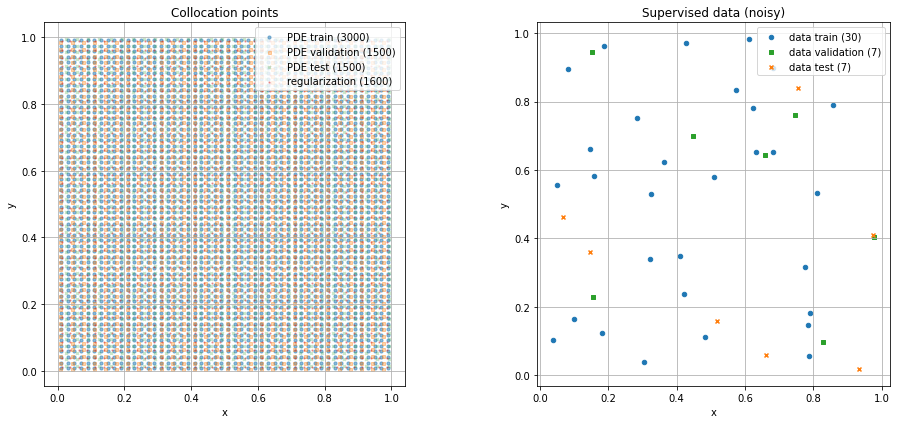

In [62]:
plot_points()


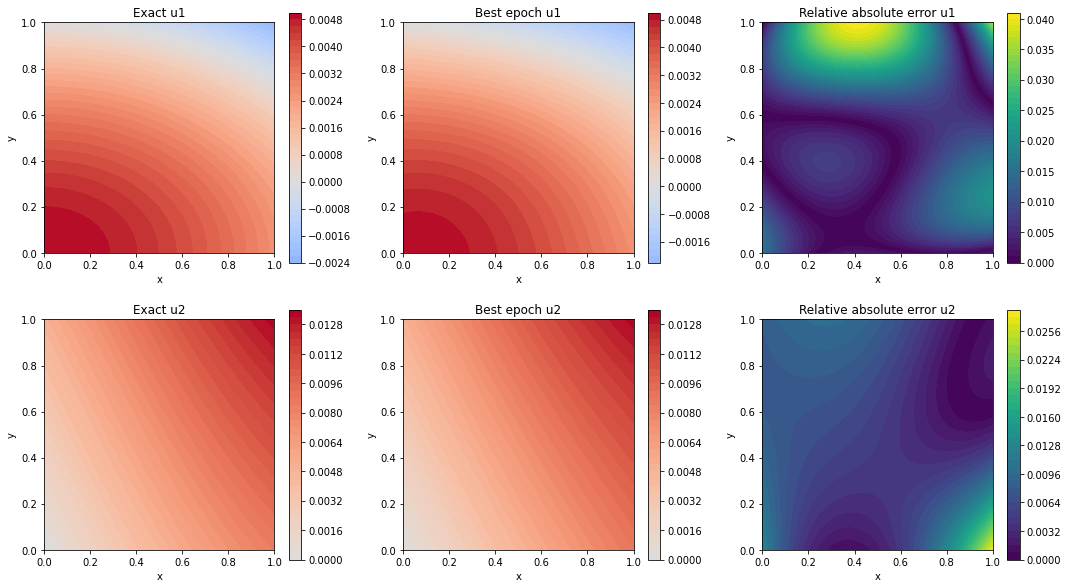

In [63]:
plot_displacement()


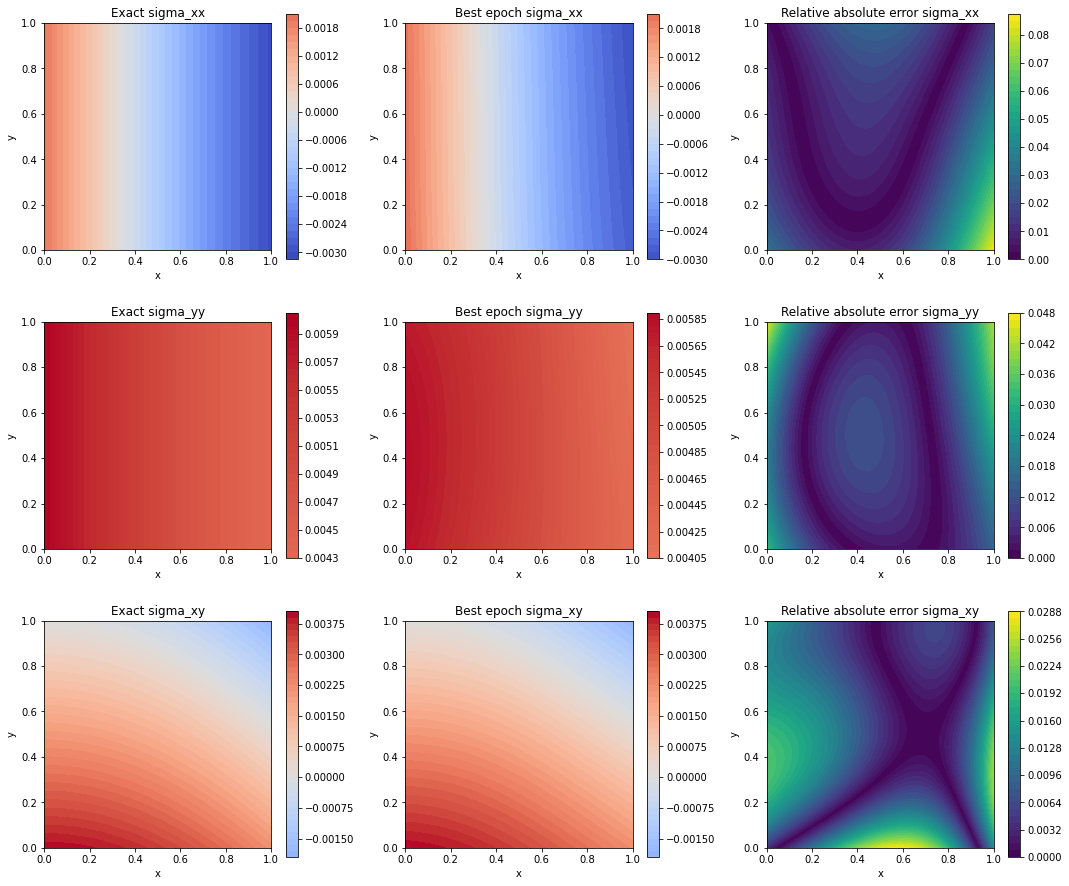

In [64]:
plot_stress()


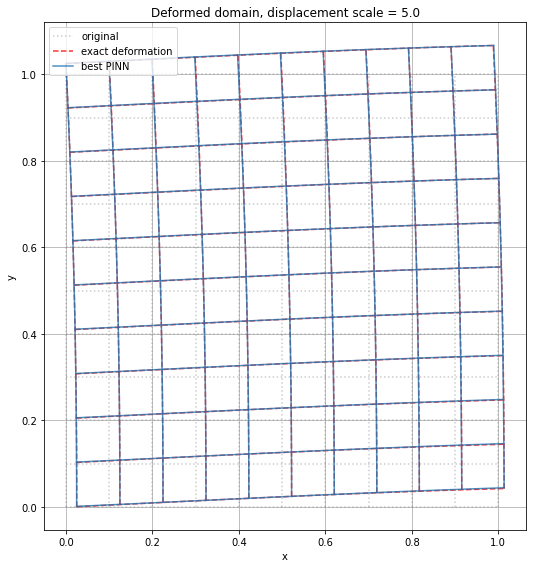

In [65]:
plot_deformed_domain(scale=5.0)


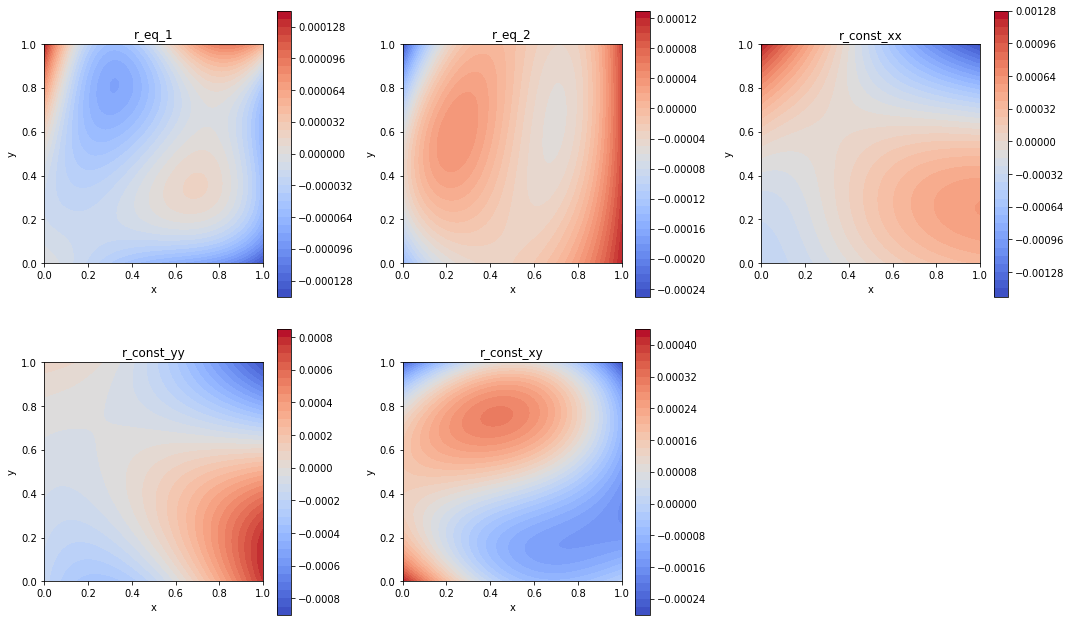

In [66]:
plot_residuals()


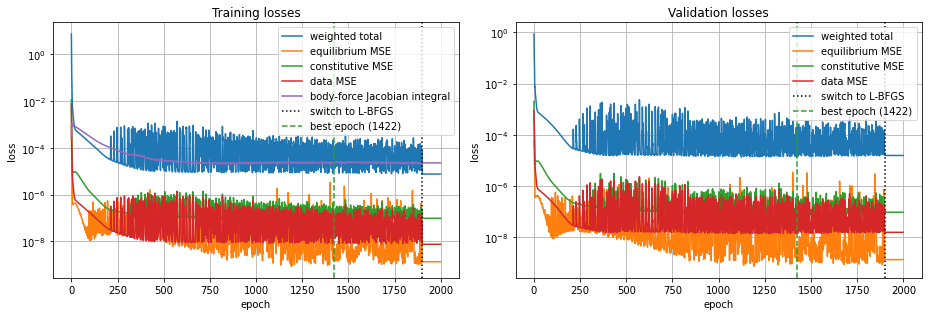

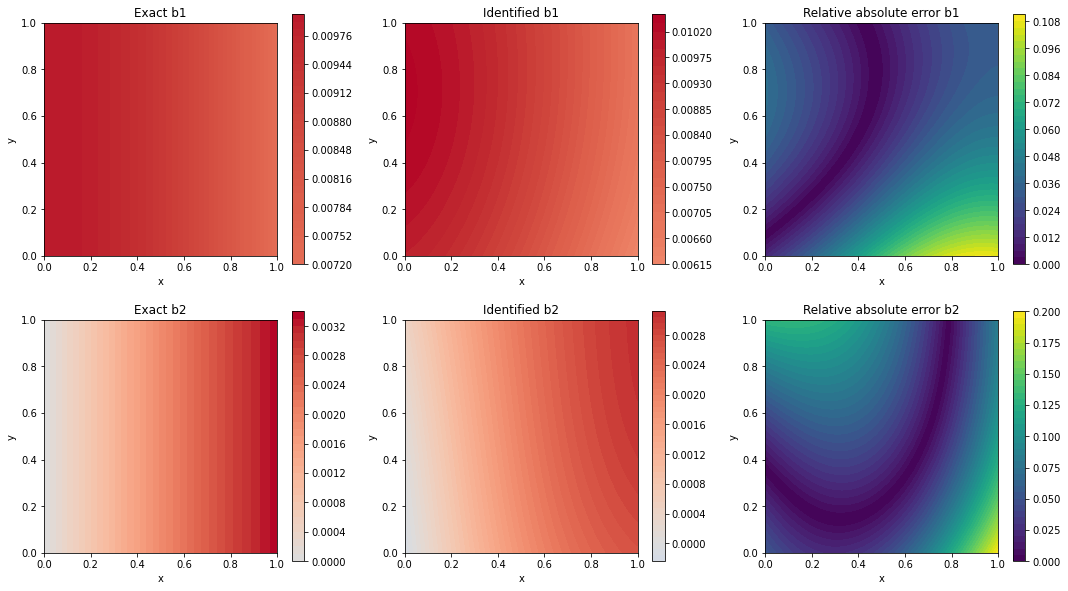

In [67]:
plot_loss()
plot_body_force()
